FIR Filter Coefficients:
[-1.24904729e-18 -1.05623580e-03 -7.69341020e-04  9.56323224e-04
  1.97608274e-03 -2.62069141e-18 -3.26538480e-03 -2.56851985e-03
  3.23463313e-03  6.51990808e-03 -6.21170236e-18 -9.82573911e-03
 -7.36568541e-03  8.88134892e-03  1.72560570e-02 -1.06504360e-17
 -2.47842717e-02 -1.84176668e-02  2.22995343e-02  4.42224439e-02
 -1.42414469e-17 -7.14698092e-02 -6.04303288e-02  9.23176270e-02
  3.02027315e-01  4.00523418e-01  3.02027315e-01  9.23176270e-02
 -6.04303288e-02 -7.14698092e-02 -1.42414469e-17  4.42224439e-02
  2.22995343e-02 -1.84176668e-02 -2.47842717e-02 -1.06504360e-17
  1.72560570e-02  8.88134892e-03 -7.36568541e-03 -9.82573911e-03
 -6.21170236e-18  6.51990808e-03  3.23463313e-03 -2.56851985e-03
 -3.26538480e-03 -2.62069141e-18  1.97608274e-03  9.56323224e-04
 -7.69341020e-04 -1.05623580e-03 -1.24904729e-18]


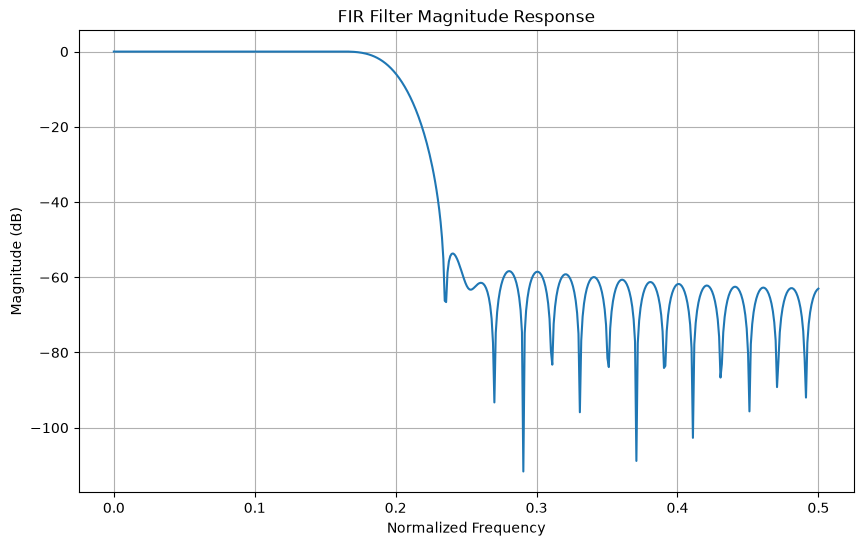

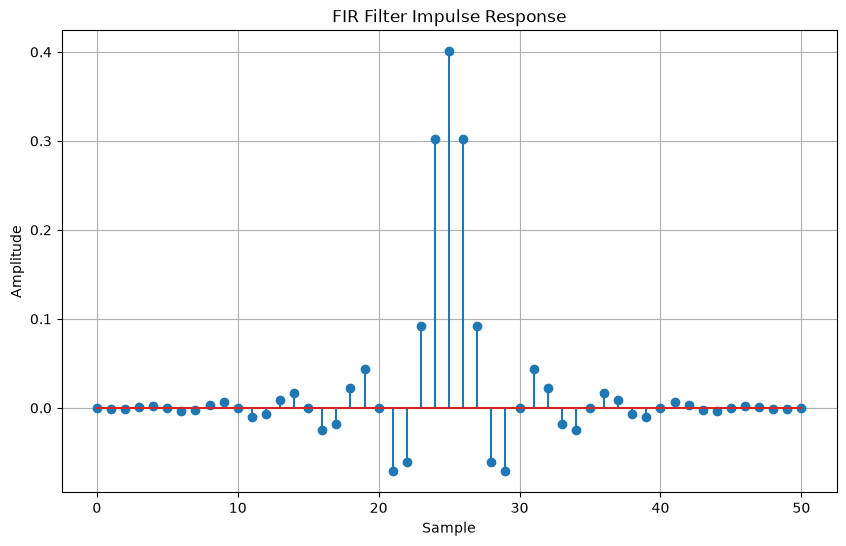


Filter coefficients saved at: fir_filter_coefficients.txt


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def design_fir_filter(cutoff_freq, filter_length, window_type='hamming'):
    if filter_length % 2 == 0:
        filter_length += 1

    n = np.arange(filter_length)
    M = (filter_length - 1) / 2
    h_ideal = np.zeros(filter_length)

    for i in range(filter_length):
        if n[i] == M:
            h_ideal[i] = 2 * cutoff_freq
        else:
            h_ideal[i] = (
                np.sin(2 * np.pi * cutoff_freq * (n[i] - M))
                / (np.pi * (n[i] - M))
            )

    if window_type.lower() == 'hamming':
        window = np.hamming(filter_length)
    elif window_type.lower() == 'hann':
        window = np.hanning(filter_length)
    elif window_type.lower() == 'blackman':
        window = np.blackman(filter_length)
    else:
        window = np.ones(filter_length)
    # Apply window
    filter_coefficients = h_ideal * window
    # Normalize filter coefficients
    filter_coefficients /= np.sum(filter_coefficients)
    return filter_coefficients


# Function to plot filter response
def plot_filter_response(filter_coefficients):

    # Compute frequency response using FFT
    frequency_response = np.fft.fft(filter_coefficients, 1024)

    # Keep only positive frequencies
    frequency_response = frequency_response[:512]

    # Frequency axis
    frequency = np.linspace(0, 0.5, 512)

    # Magnitude response in dB
    magnitude_response = 20 * np.log10(
        np.maximum(np.abs(frequency_response), 1e-10)
    )

    # Plot magnitude response
    plt.figure(figsize=(10, 6))
    plt.plot(frequency, magnitude_response)
    plt.title('FIR Filter Magnitude Response')
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Magnitude (dB)')
    plt.grid(True)
    plt.show()

    # Plot impulse response
    plt.figure(figsize=(10, 6))
    plt.stem(
        np.arange(len(filter_coefficients)),
        filter_coefficients
    )
    plt.title('FIR Filter Impulse Response')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()

# Desired filter specifications
cutoff_frequency = 0.2
filter_length = 51
window_type = 'hamming'

# Design FIR filter
filter_coefficients = design_fir_filter(
    cutoff_frequency,
    filter_length,
    window_type
)

# Display filter coefficients
print("FIR Filter Coefficients:")
print(filter_coefficients)

# Plot magnitude and impulse response
plot_filter_response(filter_coefficients)

# Save filter coefficients
filter_path = 'fir_filter_coefficients.txt'

np.savetxt(
    filter_path,
    filter_coefficients,
    delimiter=','
)

print(f"\nFilter coefficients saved at: {filter_path}")